# 03 — Pipeline Evaluation

Evaluates three configurations on the filtered test set:
1. **Transformer only** — V6 DistilBERT, no RAG, no LLM
2. **Transformer + RAG** — confidence gate + retrieval, no LLM
3. **Full pipeline** — Stage 1 rewrite + transformer + RAG + LLM

This lets you compare directly:
- Does Stage 1 (rewriting) help or hurt the transformer?
- Does RAG improve over transformer alone?
- Does the LLM add value on top of RAG?

**Resume support:** Every result is saved to `eval_results/` as it completes.
If you rerun, already-completed rows are skipped.

**Token rotation:** Provide up to 6 Groq API keys. When one is exhausted
(429 rate limit), the next is used automatically. When all are exhausted,
the run stops gracefully and saves progress.

**LLM model:** Uses `meta-llama/llama-4-scout-17b-16e-instruct` — 500K tokens/day,
much better throughput than 70b for bulk eval.

## 0. Imports & Config

In [1]:
import os, sys, json, time, re, pickle, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import faiss
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
from groq import Groq
from groq import RateLimitError
from sentence_transformers import SentenceTransformer, CrossEncoder
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from rank_bm25 import BM25Okapi
warnings.filterwarnings('ignore')

ROOT = os.path.abspath('.')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

load_dotenv('secrets.env')
HF_TOKEN = os.getenv('HF_TOKEN')

# ── Configuration ──────────────────────────────────────────────────────
TRANSFORMER_MODEL_ID = 'Nethra19/multitask-ticket-model-v6'
RAG_REPO_ID          = 'Nethra19/rag-index-v6'
EVAL_MODEL           = 'meta-llama/llama-4-scout-17b-16e-instruct'
STAGE1_MODEL         = 'meta-llama/llama-4-scout-17b-16e-instruct'

TEST_CSV    = './outputs/test_filtered.csv'
RESULTS_DIR = Path('./eval_results')
RESULTS_DIR.mkdir(exist_ok=True)

SEED      = 42
N_SAMPLES = 300   # how many test rows to evaluate — large enough for significance

# Per-class thresholds (from V6 Cell 15)
DEPT_THRESHOLDS = {
    'Billing and Payments':            0.72,
    'Customer Service':                0.60,
    'General Inquiry':                 0.65,
    'Human Resources':                 0.65,
    'Returns and Exchanges':           0.72,
    'Sales and Pre-Sales':             0.72,
    'Service Outages and Maintenance': 0.60,
    'Technical & IT Support':          0.72,
}
PRIORITY_THRESHOLD = 0.65
RAG_GAP_UNCERTAIN  = 0.15

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Results dir: {RESULTS_DIR.resolve()}')

Device: cuda
Results dir: C:\Users\nethr\UCD Spring\ML\Project\New_trial\eval_results


## 1. Groq Token Rotation Setup

In [2]:
# ── Add up to 6 Groq API keys here ────────────────────────────────────
# When one exhausts (429), moves to next automatically
# When all exhausted, eval stops and saves progress
GROQ_TOKENS = [
    os.getenv('GROQ_API_KEY'),        # from secrets.env
    os.getenv('GROQ_API_KEY_2', ''),  # add more in secrets.env or paste here
    os.getenv('GROQ_API_KEY_3', ''),
    os.getenv('GROQ_API_KEY_4', ''),
    os.getenv('GROQ_API_KEY_5', ''),
    os.getenv('GROQ_API_KEY_6', ''),
]
GROQ_TOKENS = [t for t in GROQ_TOKENS if t]  # remove empty

print(f'{len(GROQ_TOKENS)} Groq token(s) loaded')
for i, t in enumerate(GROQ_TOKENS):
    print(f'  Token {i+1}: {t[:8]}...')


class TokenRotator:
    """Rotates through Groq API keys on rate limit exhaustion."""

    def __init__(self, tokens: list):
        self.tokens    = tokens
        self.idx       = 0
        self.exhausted = False
        self.client    = Groq(api_key=tokens[0]) if tokens else None

    def call(self, model: str, messages: list, temperature=0.0, max_tokens=500) -> str:
        """Make a Groq call, rotating token on 429. Returns None if all exhausted."""
        while self.idx < len(self.tokens):
            try:
                resp = self.client.chat.completions.create(
                    model=model,
                    messages=messages,
                    temperature=temperature,
                    max_tokens=max_tokens,
                )
                return resp.choices[0].message.content.strip()
            except RateLimitError:
                print(f'  ⚠ Token {self.idx+1} exhausted — trying next...')
                self.idx += 1
                if self.idx < len(self.tokens):
                    self.client = Groq(api_key=self.tokens[self.idx])
                else:
                    self.exhausted = True
                    print('  ✗ All tokens exhausted — stopping eval')
                    return None
            except Exception as e:
                print(f'  ⚠ Groq error: {e} — skipping')
                return None
        self.exhausted = True
        return None

    @property
    def current_token_num(self):
        return self.idx + 1


rotator = TokenRotator(GROQ_TOKENS)
print(f'Token rotator ready — starting with token 1')

6 Groq token(s) loaded
  Token 1: gsk_FddI...
  Token 2: gsk_FKyR...
  Token 3: gsk_7Cmd...
  Token 4: gsk_fXaM...
  Token 5: gsk_LqUY...
  Token 6: gsk_qfBp...
Token rotator ready — starting with token 1


## 2. Load Models and Artifacts

In [3]:
from pipeline.stage2a_transformer import MultiTaskModel, clean_text
from huggingface_hub import hf_hub_download

print('Loading V6 transformer...')
tokenizer        = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL_ID, token=HF_TOKEN)
queue_encoder    = joblib.load(hf_hub_download(TRANSFORMER_MODEL_ID, 'queue_encoder.pkl',    token=HF_TOKEN))
priority_encoder = joblib.load(hf_hub_download(TRANSFORMER_MODEL_ID, 'priority_encoder.pkl', token=HF_TOKEN))
heads_path       = hf_hub_download(TRANSFORMER_MODEL_ID, 'heads.pt', token=HF_TOKEN)

model = MultiTaskModel(
    TRANSFORMER_MODEL_ID,
    len(queue_encoder.classes_),
    len(priority_encoder.classes_)
)
heads = torch.load(heads_path, map_location=device, weights_only=False)
model.queue_classifier.load_state_dict(heads['queue_classifier'])
model.priority_classifier.load_state_dict(heads['priority_classifier'])
model.to(device).eval()
print(f'  Transformer ready: {len(queue_encoder.classes_)} depts, {len(priority_encoder.classes_)} priorities')

print('Loading RAG artifacts...')
from huggingface_hub import hf_hub_download

faiss_index = faiss.read_index(
    hf_hub_download(RAG_REPO_ID, 'rag_compliance_index.faiss', token=HF_TOKEN, repo_type='model')
)
with open(hf_hub_download(RAG_REPO_ID, 'rag_bm25_index.pkl', token=HF_TOKEN, repo_type='model'), 'rb') as f:
    bm25_data = pickle.load(f)
bm25 = bm25_data['bm25']

with open(hf_hub_download(RAG_REPO_ID, 'rag_compliance_metadata.pkl', token=HF_TOKEN, repo_type='model'), 'rb') as f:
    all_chunks = pickle.load(f)

priority_index = faiss.read_index(
    hf_hub_download(RAG_REPO_ID, 'rag_priority_index.faiss', token=HF_TOKEN, repo_type='model')
)
with open(hf_hub_download(RAG_REPO_ID, 'rag_priority_metadata.pkl', token=HF_TOKEN, repo_type='model'), 'rb') as f:
    priority_chunks = pickle.load(f)

embedder      = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
cross_encoder = CrossEncoder('BAAI/bge-reranker-base')

print(f'  RAG ready: {faiss_index.ntotal} dept vectors, {priority_index.ntotal} priority vectors')
print('\n✓ All components loaded')

Loading V6 transformer...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

  Transformer ready: 8 depts, 3 priorities
Loading RAG artifacts...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  RAG ready: 72 dept vectors, 3 priority vectors

✓ All components loaded


## 3. Load and Sample Test Set

In [4]:
df_test = pd.read_csv(TEST_CSV)
print(f'Full test set: {len(df_test):,} rows')
print(f'\nClass distribution:')
print(df_test['queue'].value_counts())

# Stratified sample — maintain class proportions
df_eval = (
    df_test
    .groupby('queue', group_keys=False)
    .apply(lambda x: x.sample(
        min(len(x), max(1, int(N_SAMPLES * len(x) / len(df_test)))),
        random_state=SEED
    ))
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print(f'\nEval sample: {len(df_eval):,} rows (stratified)')
print(df_eval['queue'].value_counts())
print(f'\nPriority distribution in sample:')
print(df_eval['priority'].value_counts())

Full test set: 572 rows

Class distribution:
queue
Returns and Exchanges              105
Technical & IT Support             105
Billing and Payments               102
Sales and Pre-Sales                 95
Human Resources                     60
General Inquiry                     46
Customer Service                    36
Service Outages and Maintenance     23
Name: count, dtype: int64

Eval sample: 297 rows (stratified)
queue
Returns and Exchanges              55
Technical & IT Support             55
Billing and Payments               53
Sales and Pre-Sales                49
Human Resources                    31
General Inquiry                    24
Customer Service                   18
Service Outages and Maintenance    12
Name: count, dtype: int64

Priority distribution in sample:
priority
medium    209
high       82
low         6
Name: count, dtype: int64


## 4. Helper Functions

In [5]:
def tokenize_for_bm25(text):
    return re.sub(r'[^\w\s]', ' ', text.lower()).split()


def run_transformer(text: str) -> dict:
    """Run V6 transformer on text. Returns dept, priority, and confidence scores."""
    cleaned = clean_text(text)
    inputs  = tokenizer(cleaned, return_tensors='pt',
                        truncation=True, padding=True, max_length=128)
    inputs  = {k: v.to(device) for k, v in inputs.items() if k != 'token_type_ids'}

    with torch.no_grad():
        q_logits, p_logits = model(**inputs)
        q_probs = F.softmax(q_logits, dim=1)[0]
        p_probs = F.softmax(p_logits, dim=1)[0]

    q_id = q_probs.argmax().item()
    p_id = p_probs.argmax().item()

    return {
        'dept':          queue_encoder.classes_[q_id],
        'dept_conf':     round(q_probs[q_id].item(), 4),
        'priority':      priority_encoder.classes_[p_id],
        'priority_conf': round(p_probs[p_id].item(), 4),
        'top3': [
            {'dept': queue_encoder.classes_[i], 'prob': round(q_probs[i].item(), 4)}
            for i in q_probs.topk(3).indices.tolist()
        ],
        'priority_probs': {
            priority_encoder.classes_[i]: round(p_probs[i].item(), 4)
            for i in range(len(priority_encoder.classes_))
        },
    }


def run_rag(text: str, transformer_result: dict) -> dict:
    """
    Run RAG retrieval based on transformer confidence.
    Returns dept decision (from RAG top chunk dept label) and rag_gap.
    """
    predicted_dept = transformer_result['dept']
    dept_conf      = transformer_result['dept_conf']
    priority_conf  = transformer_result['priority_conf']
    dept_threshold = DEPT_THRESHOLDS.get(predicted_dept, 0.70)

    dept_confident     = dept_conf     >= dept_threshold
    priority_confident = priority_conf >= PRIORITY_THRESHOLD

    # Fast path
    if dept_confident and priority_confident:
        return {
            'dept':           predicted_dept,
            'priority':       transformer_result['priority'],
            'fast_path':      True,
            'rag_gap':        0.0,
            'retrieved_dept': None,
        }

    # Retrieve dept chunks
    retrieved_dept = predicted_dept
    rag_gap        = 0.0
    if not dept_confident:
        q_emb = embedder.encode([text], normalize_embeddings=True).astype('float32')
        _, dense_ids = faiss_index.search(q_emb, 10)
        dense_ids    = dense_ids[0].tolist()

        bm25_scores  = bm25.get_scores(tokenize_for_bm25(text))
        bm25_ids     = np.argsort(bm25_scores)[::-1][:10].tolist()

        rrf = {}
        for rank, idx in enumerate(dense_ids):
            rrf[idx] = rrf.get(idx, 0) + 1.0 / (60 + rank + 1)
        for rank, idx in enumerate(bm25_ids):
            rrf[idx] = rrf.get(idx, 0) + 1.0 / (60 + rank + 1)

        candidate_ids = [i for i, _ in sorted(rrf.items(), key=lambda x: x[1], reverse=True)[:20]]
        ce_scores     = cross_encoder.predict([[text, all_chunks[i]['text']] for i in candidate_ids])
        ranked        = sorted(zip(candidate_ids, ce_scores), key=lambda x: x[1], reverse=True)

        retrieved_dept = all_chunks[ranked[0][0]]['dept']
        rag_gap        = float(ranked[0][1] - ranked[1][1]) if len(ranked) >= 2 else 1.0

    return {
        'dept':           retrieved_dept if not dept_confident else predicted_dept,
        'priority':       transformer_result['priority'],  # priority from transformer for RAG-only eval
        'fast_path':      dept_confident and priority_confident,
        'rag_gap':        rag_gap,
        'retrieved_dept': retrieved_dept if not dept_confident else None,
    }


def run_stage1(text: str) -> str:
    """Rewrite ticket using Stage 1 LLM. Returns cleaned text or original on failure."""
    prompt = (
        "You are a customer-support triage assistant. "
        "Given a raw support ticket, return ONLY valid JSON with these keys:\n"
        "  structured_body: cleaned, professional rewrite of the ticket\n"
        "  subject: concise 6-10 word subject line\n"
        "  urgency_signals: list of urgency phrases found\n"
        "  tech_keywords: list of technical terms found\n"
        "  explanation: one sentence explaining the likely department\n"
        "Return nothing outside the JSON object.\n"
        "IMPORTANT: In structured_body, rewrite only what the customer said. "
        "Preserve the customer's original vocabulary. "
        "Do NOT add department-specific vocabulary that was not in the original ticket.\n"
        f"TICKET:\n{text.strip()}"
    )
    raw = rotator.call(STAGE1_MODEL, [{'role': 'user', 'content': prompt}],
                       temperature=0.0, max_tokens=500)
    if raw is None:
        return text  # fallback to original

    # Extract structured_body
    s = re.sub(r'^```(?:json)?\s*', '', raw, flags=re.IGNORECASE).strip()
    s = re.sub(r'\s*```\s*$', '', s).strip()
    try:
        obj = json.loads(s)
        return obj.get('structured_body', text).strip()
    except Exception:
        m = re.search(r'"structured_body"\s*:\s*"(.*?)(?:"|$)', s, re.DOTALL)
        if m:
            return m.group(1).strip().rstrip('",') or text
        return text


VALID_DEPTS = list(queue_encoder.classes_)

def run_full_pipeline(text: str, transformer_result: dict, rag_result: dict) -> dict:
    """
    Run Stage 3 LLM with transformer + RAG signals.
    Returns dept and priority decision.
    """
    predicted_dept  = transformer_result['dept']
    dept_conf       = transformer_result['dept_conf']
    priority_conf   = transformer_result['priority_conf']
    dept_threshold  = DEPT_THRESHOLDS.get(predicted_dept, 0.70)
    dept_confident  = dept_conf     >= dept_threshold
    prio_confident  = priority_conf >= PRIORITY_THRESHOLD
    rag_gap         = rag_result['rag_gap']

    # Fast path — skip LLM
    if rag_result['fast_path']:
        return {'dept': predicted_dept, 'priority': transformer_result['priority'],
                'fast_path': True, 'llm_called': False}

    top3_lines = '\n'.join(
        f"  {i+1}. {r['dept']} — {r['prob']*100:.1f}%"
        for i, r in enumerate(transformer_result['top3'])
    )
    instruction_note = (
        '⚠ BOTH transformer and RAG uncertain. Reason from ticket text. Set confidence low.'
        if not dept_confident and rag_gap < RAG_GAP_UNCERTAIN
        else ('Department uncertain — use RAG chunks.' if not dept_confident
              else 'Priority uncertain — use priority criteria.')
    )

    prompt = f"""You are a support ticket routing system. {instruction_note}

TICKET: {text}

TRANSFORMER: {predicted_dept} ({dept_conf*100:.1f}%) [{'CONFIDENT' if dept_confident else 'UNCERTAIN'}]
Priority: {transformer_result['priority']} ({priority_conf*100:.1f}%) [{'CONFIDENT' if prio_confident else 'UNCERTAIN'}]
Top-3: {top3_lines}

RAG TOP DEPT: {rag_result.get('retrieved_dept', 'N/A')} | GAP={rag_gap:.3f}

VALID DEPARTMENTS: {', '.join(VALID_DEPTS)}
VALID PRIORITIES: high, medium, low

Respond ONLY with valid JSON:
{{"department": "<exact dept name>", "priority": "<high|medium|low>", "confidence": "<high|medium|low>", "reasoning": "<1 sentence>"}}"""

    raw = rotator.call(EVAL_MODEL, [{'role': 'user', 'content': prompt}],
                       temperature=0.0, max_tokens=200)
    if raw is None:
        return {'dept': rag_result['dept'], 'priority': transformer_result['priority'],
                'fast_path': False, 'llm_called': False}

    try:
        m = re.search(r'\{.*?\}', raw, re.DOTALL)
        result = json.loads(m.group()) if m else {}
        dept     = result.get('department', rag_result['dept'])
        priority = result.get('priority', transformer_result['priority'])
        if dept not in VALID_DEPTS:      dept     = rag_result['dept']
        if priority not in ('high','medium','low'): priority = transformer_result['priority']
        return {'dept': dept, 'priority': priority, 'fast_path': False, 'llm_called': True}
    except Exception:
        return {'dept': rag_result['dept'], 'priority': transformer_result['priority'],
                'fast_path': False, 'llm_called': False}

print('Helper functions defined.')

Helper functions defined.


## 5. Run Evaluation (with resume support)

In [6]:
RESULTS_FILE = RESULTS_DIR / 'eval_rows.jsonl'

# ── Load already-completed rows ────────────────────────────────────────
completed_ids = set()
if RESULTS_FILE.exists():
    with open(RESULTS_FILE, 'r') as f:
        for line in f:
            try:
                row = json.loads(line)
                completed_ids.add(row['eval_id'])
            except Exception:
                pass
    print(f'Resuming — {len(completed_ids)} rows already completed')
else:
    print('Starting fresh eval run')

remaining = df_eval[~df_eval.index.isin(completed_ids)]
print(f'Rows to process: {len(remaining)} / {len(df_eval)}')

# ── Eval loop ──────────────────────────────────────────────────────────
n_processed = 0
n_stage1_calls = 0
n_llm_calls    = 0

with open(RESULTS_FILE, 'a') as fout:
    for eval_id, row in remaining.iterrows():
        if rotator.exhausted:
            print(f'\nAll Groq tokens exhausted after {n_processed} rows. Save complete.')
            break

        raw_text      = str(row['text'])
        true_dept     = str(row['queue'])
        true_priority = str(row['priority'])

        # ── Eval 1: Transformer on RAW text (no Stage 1, no RAG) ──────
        trans_raw = run_transformer(raw_text)

        # ── Eval 2: Stage 1 rewrite → Transformer ─────────────────────
        rewritten = run_stage1(raw_text)
        n_stage1_calls += 1
        trans_rewritten = run_transformer(rewritten)

        if rotator.exhausted:
            print(f'Token exhausted during Stage 1 at row {eval_id}')
            break

        # ── Eval 3: RAG on rewritten text ─────────────────────────────
        rag_result = run_rag(rewritten, trans_rewritten)

        # ── Eval 4: Full pipeline (Stage1 + Transformer + RAG + LLM) ──
        full_result = run_full_pipeline(rewritten, trans_rewritten, rag_result)
        if full_result.get('llm_called'):
            n_llm_calls += 1

        if rotator.exhausted:
            print(f'Token exhausted during LLM at row {eval_id}')
            break

        # ── Save row ───────────────────────────────────────────────────
        result_row = {
            'eval_id':           eval_id,
            'true_dept':         true_dept,
            'true_priority':     true_priority,
            'raw_text':          raw_text[:300],
            'rewritten_text':    rewritten[:300],

            # Transformer on raw (no Stage 1)
            'trans_raw_dept':     trans_raw['dept'],
            'trans_raw_dept_conf': trans_raw['dept_conf'],
            'trans_raw_priority': trans_raw['priority'],

            # Transformer on rewritten (Stage 1 applied)
            'trans_rew_dept':     trans_rewritten['dept'],
            'trans_rew_dept_conf': trans_rewritten['dept_conf'],
            'trans_rew_priority': trans_rewritten['priority'],

            # RAG decision
            'rag_dept':           rag_result['dept'],
            'rag_priority':       rag_result['priority'],
            'rag_fast_path':      rag_result['fast_path'],
            'rag_gap':            rag_result['rag_gap'],

            # Full pipeline decision
            'full_dept':          full_result['dept'],
            'full_priority':      full_result['priority'],
            'full_fast_path':     full_result['fast_path'],
            'full_llm_called':    full_result['llm_called'],

            'timestamp': datetime.now().isoformat(),
        }
        fout.write(json.dumps(result_row) + '\n')
        fout.flush()
        n_processed += 1

        if n_processed % 10 == 0:
            total_done = len(completed_ids) + n_processed
            print(f'  [{total_done}/{len(df_eval)}] processed | '
                  f'Stage1 calls: {n_stage1_calls} | '
                  f'LLM calls: {n_llm_calls} | '
                  f'Token: {rotator.current_token_num}/{len(GROQ_TOKENS)}')

total_done = len(completed_ids) + n_processed
print(f'\nDone. {total_done}/{len(df_eval)} rows complete.')
print(f'Results saved to: {RESULTS_FILE}')

Starting fresh eval run
Rows to process: 297 / 297
  [10/297] processed | Stage1 calls: 10 | LLM calls: 5 | Token: 1/6
  [20/297] processed | Stage1 calls: 20 | LLM calls: 9 | Token: 1/6
  [30/297] processed | Stage1 calls: 30 | LLM calls: 13 | Token: 1/6
  [40/297] processed | Stage1 calls: 40 | LLM calls: 18 | Token: 1/6
  [50/297] processed | Stage1 calls: 50 | LLM calls: 25 | Token: 1/6
  [60/297] processed | Stage1 calls: 60 | LLM calls: 29 | Token: 1/6
  [70/297] processed | Stage1 calls: 70 | LLM calls: 31 | Token: 1/6
  [80/297] processed | Stage1 calls: 80 | LLM calls: 33 | Token: 1/6
  [90/297] processed | Stage1 calls: 90 | LLM calls: 39 | Token: 1/6
  [100/297] processed | Stage1 calls: 100 | LLM calls: 42 | Token: 1/6
  [110/297] processed | Stage1 calls: 110 | LLM calls: 45 | Token: 1/6
  [120/297] processed | Stage1 calls: 120 | LLM calls: 48 | Token: 1/6
  [130/297] processed | Stage1 calls: 130 | LLM calls: 50 | Token: 1/6
  [140/297] processed | Stage1 calls: 140 | LL

## 6. Load Results and Compute Metrics

In [7]:
# Load all completed rows
rows = []
with open(RESULTS_FILE, 'r') as f:
    for line in f:
        try:
            rows.append(json.loads(line))
        except Exception:
            pass

df_results = pd.DataFrame(rows)
print(f'Loaded {len(df_results)} completed rows')

# ── Department accuracy ────────────────────────────────────────────────
configs = [
    ('Transformer (raw text)',      'trans_raw_dept'),
    ('Transformer (Stage1 rewrite)','trans_rew_dept'),
    ('RAG + Transformer',           'rag_dept'),
    ('Full Pipeline (+ LLM)',       'full_dept'),
]

print('\n' + '='*65)
print('DEPARTMENT ROUTING RESULTS')
print('='*65)
print(f'{"Config":<35} {"Accuracy":>10} {"Macro F1":>10} {"Weighted F1":>12}')
print('-'*65)

dept_metrics = {}
y_true = df_results['true_dept']

for name, col in configs:
    y_pred   = df_results[col]
    acc      = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    wt_f1    = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    dept_metrics[name] = {'acc': acc, 'macro_f1': macro_f1, 'weighted_f1': wt_f1}
    print(f'{name:<35} {acc:>10.3f} {macro_f1:>10.3f} {wt_f1:>12.3f}')

print('='*65)

# ── Priority accuracy ──────────────────────────────────────────────────
p_configs = [
    ('Transformer (raw)',    'trans_raw_priority'),
    ('Transformer (Stage1)', 'trans_rew_priority'),
    ('Full Pipeline',        'full_priority'),
]

print('\nPRIORITY RESULTS')
print('='*65)
print(f'{"Config":<35} {"Accuracy":>10} {"Macro F1":>10}')
print('-'*65)

p_true = df_results['true_priority']
for name, col in p_configs:
    p_pred   = df_results[col]
    acc      = accuracy_score(p_true, p_pred)
    macro_f1 = f1_score(p_true, p_pred, average='macro', zero_division=0)
    print(f'{name:<35} {acc:>10.3f} {macro_f1:>10.3f}')

print('='*65)

# ── Stage 1 impact ─────────────────────────────────────────────────────
raw_acc = accuracy_score(y_true, df_results['trans_raw_dept'])
rew_acc = accuracy_score(y_true, df_results['trans_rew_dept'])
delta   = rew_acc - raw_acc
print(f'\nStage 1 impact on transformer dept accuracy: {delta:+.3f} '
      f'({"✓ helps" if delta > 0 else "✗ hurts" if delta < 0 else "= neutral"})')

# ── Fast path stats ────────────────────────────────────────────────────
fast_pct = df_results['full_fast_path'].mean() * 100
llm_pct  = df_results['full_llm_called'].mean() * 100
print(f'\nFast path (RAG+LLM skipped): {fast_pct:.1f}% of tickets')
print(f'LLM called (slow path):      {llm_pct:.1f}% of tickets')

Loaded 297 completed rows

DEPARTMENT ROUTING RESULTS
Config                                Accuracy   Macro F1  Weighted F1
-----------------------------------------------------------------
Transformer (raw text)                   0.771      0.745        0.771
Transformer (Stage1 rewrite)             0.771      0.745        0.771
RAG + Transformer                        0.710      0.678        0.719
Full Pipeline (+ LLM)                    0.694      0.682        0.690

PRIORITY RESULTS
Config                                Accuracy   Macro F1
-----------------------------------------------------------------
Transformer (raw)                        0.906      0.762
Transformer (Stage1)                     0.912      0.767
Full Pipeline                            0.865      0.741

Stage 1 impact on transformer dept accuracy: +0.000 (= neutral)

Fast path (RAG+LLM skipped): 58.2% of tickets
LLM called (slow path):      41.8% of tickets


## 7. Per-Class Breakdown — Where Does Each Config Win?

In [8]:
print('PER-CLASS F1 COMPARISON')
print('='*100)
header = f'{"Department":<40}' + ''.join(f'{n[:12]:>14}' for n, _ in configs)
print(header)
print('-'*100)

classes = sorted(df_results['true_dept'].unique())
per_class = {}

for dept in classes:
    mask    = y_true == dept
    row_str = f'{dept:<40}'
    per_class[dept] = {}
    for name, col in configs:
        if mask.sum() == 0:
            f1 = 0.0
        else:
            f1 = f1_score(y_true[mask], df_results[col][mask],
                          labels=[dept], average='macro', zero_division=0)
        per_class[dept][name] = f1
        row_str += f'{f1:>14.3f}'
    print(row_str)

print('='*100)

# Summary: which config wins per class?
print('\nBest config per department:')
for dept, scores in per_class.items():
    best_name = max(scores, key=scores.get)
    best_f1   = scores[best_name]
    print(f'  {dept:<40} → {best_name} (F1={best_f1:.3f})')

PER-CLASS F1 COMPARISON
Department                                Transformer   Transformer   RAG + Transf  Full Pipelin
----------------------------------------------------------------------------------------------------
Billing and Payments                             0.990         0.990         0.990         0.990
Customer Service                                 0.839         0.839         0.875         0.759
General Inquiry                                  0.769         0.737         0.667         0.667
Human Resources                                  0.760         0.784         0.708         0.652
Returns and Exchanges                            0.817         0.817         0.721         0.590
Sales and Pre-Sales                              0.833         0.833         0.775         0.759
Service Outages and Maintenance                  0.957         0.957         0.957         0.957
Technical & IT Support                           0.911         0.911         0.878         0.972

B

## 8. Stage 1 Analysis — Helps or Hurts?

In [9]:
# Row-level comparison: did Stage 1 flip a correct → wrong or wrong → correct?
df_results['raw_correct'] = df_results['trans_raw_dept'] == df_results['true_dept']
df_results['rew_correct'] = df_results['trans_rew_dept'] == df_results['true_dept']

helped  = ((~df_results['raw_correct']) & df_results['rew_correct']).sum()
hurt    = (df_results['raw_correct'] & (~df_results['rew_correct'])).sum()
neutral = ((df_results['raw_correct'] == df_results['rew_correct'])).sum()

print('Stage 1 (rewrite) impact — ticket level:')
print(f'  ✓ Fixed (wrong→correct): {helped}')
print(f'  ✗ Broke (correct→wrong): {hurt}')
print(f'  = No change:             {neutral}')
print(f'  Net impact: {helped - hurt:+d} tickets')

if hurt > 0:
    print('\nTickets BROKEN by Stage 1:')
    broken = df_results[df_results['raw_correct'] & (~df_results['rew_correct'])]
    for _, r in broken.head(5).iterrows():
        print(f'  [{r["true_dept"]}]')
        print(f'    RAW:      {r["raw_text"][:100]!r}')
        print(f'    REWRITE:  {r["rewritten_text"][:100]!r}')
        print(f'    Predicted: {r["trans_raw_dept"]} → {r["trans_rew_dept"]}')
        print()

if helped > 0:
    print('\nTickets FIXED by Stage 1:')
    fixed = df_results[(~df_results['raw_correct']) & df_results['rew_correct']]
    for _, r in fixed.head(3).iterrows():
        print(f'  [{r["true_dept"]}]')
        print(f'    RAW:      {r["raw_text"][:100]!r}')
        print(f'    REWRITE:  {r["rewritten_text"][:100]!r}')
        print(f'    Predicted: {r["trans_raw_dept"]} → {r["trans_rew_dept"]}')
        print()

Stage 1 (rewrite) impact — ticket level:
  ✓ Fixed (wrong→correct): 1
  ✗ Broke (correct→wrong): 1
  = No change:             295
  Net impact: +0 tickets

Tickets BROKEN by Stage 1:
  [General Inquiry]
    RAW:      'Is it possible to provide details on data analytics tools that could be useful for optimizing invest'
    REWRITE:  'Is it possible to provide details on data analytics tools that could be useful for optimizing invest'
    Predicted: General Inquiry → Sales and Pre-Sales


Tickets FIXED by Stage 1:
  [Human Resources]
    RAW:      'I am reporting an issue with the project management software used during our team collaboration sess'
    REWRITE:  'The project management software used during our team collaboration session crashed, possibly due to '
    Predicted: Technical & IT Support → Human Resources



## 9. Confusion Matrices

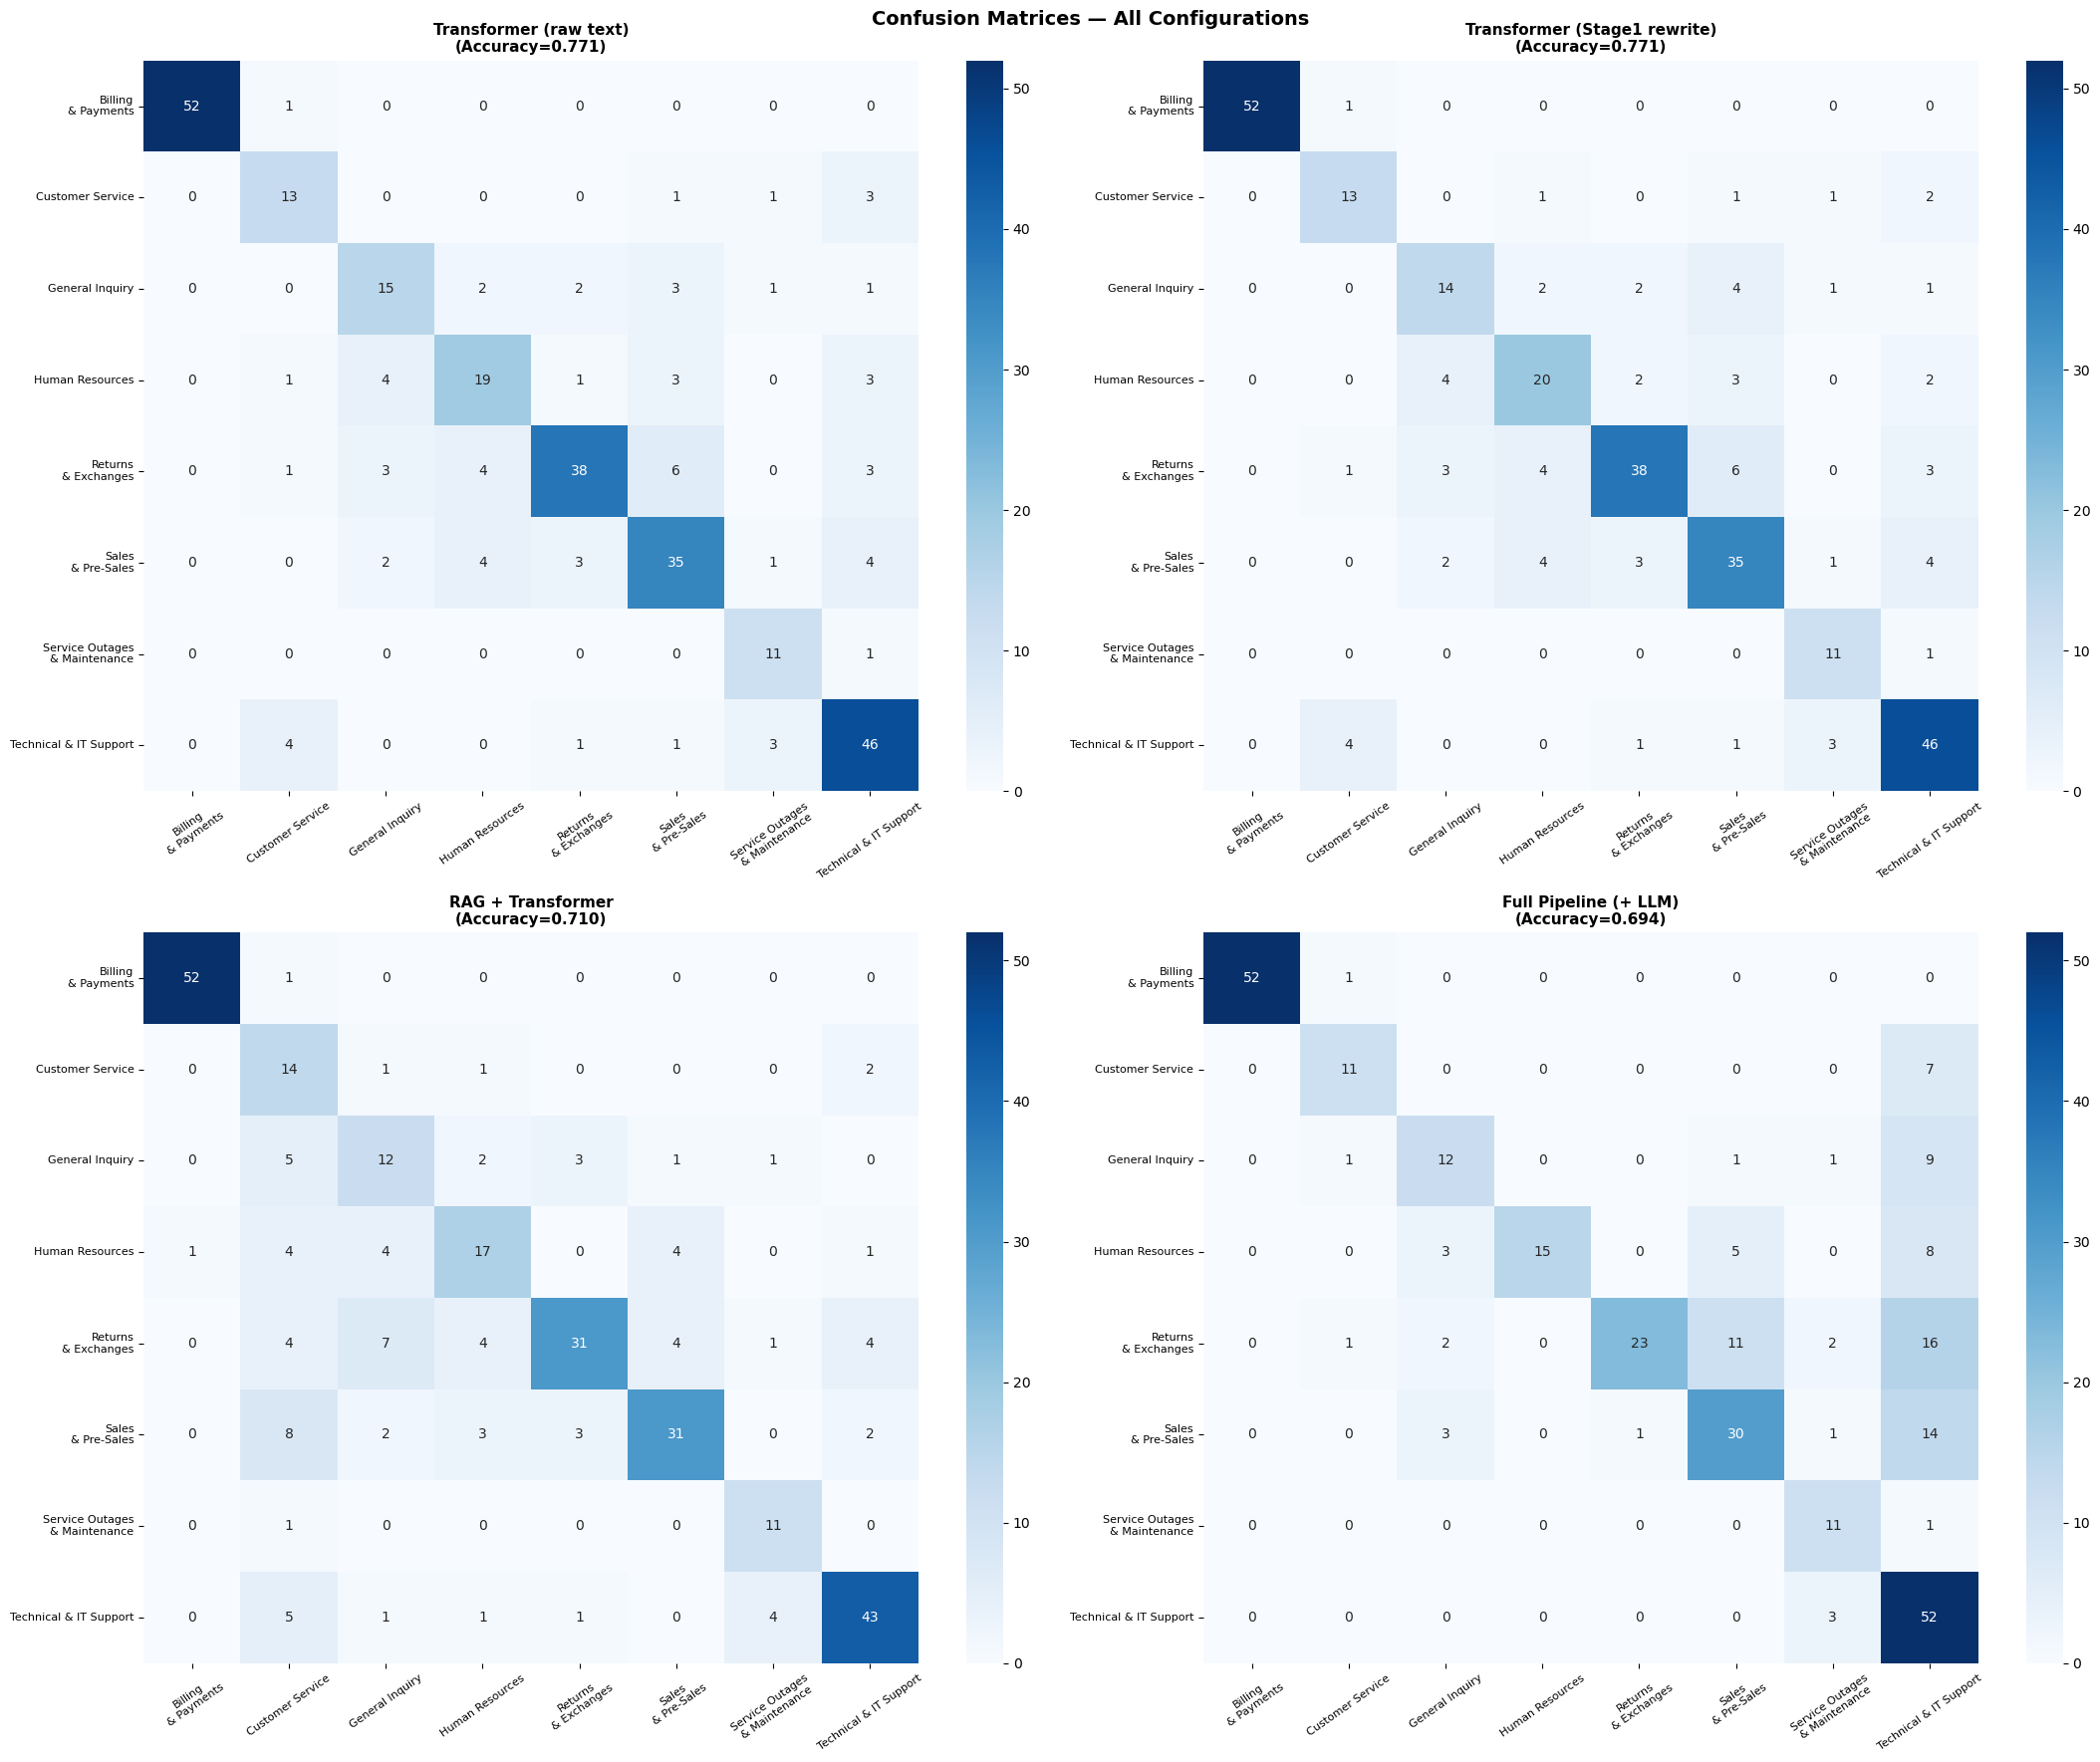

Saved → eval_results/confusion_matrices.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(22, 18))
axes = axes.flatten()

label_order = sorted(df_results['true_dept'].unique())

for ax, (name, col) in zip(axes, configs):
    cm = confusion_matrix(y_true, df_results[col], labels=label_order)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=[l.replace(' and ', '\n& ') for l in label_order],
                yticklabels=[l.replace(' and ', '\n& ') for l in label_order])
    acc = accuracy_score(y_true, df_results[col])
    ax.set_title(f'{name}\n(Accuracy={acc:.3f})', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Confusion Matrices — All Configurations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices.png', bbox_inches='tight', dpi=130)
plt.show()
print('Saved → eval_results/confusion_matrices.png')

## 10. Summary Dashboard

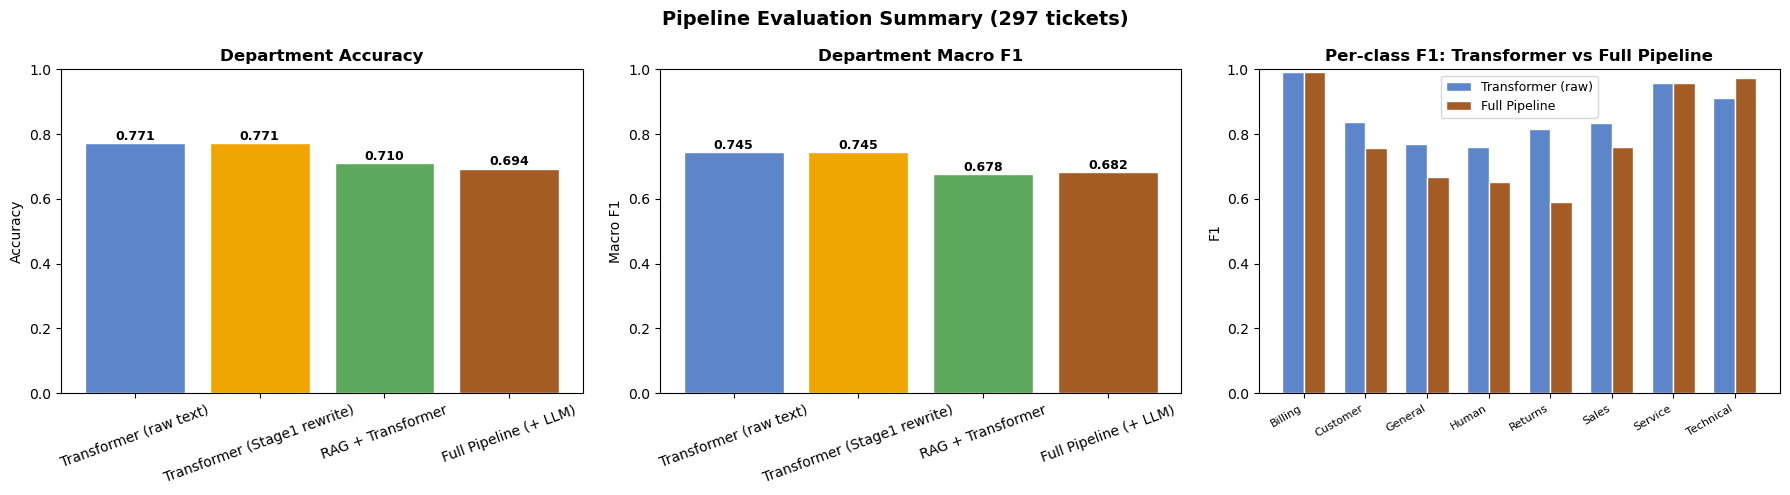

Saved → eval_results/eval_summary.png
Saved → eval_results/eval_results_full.csv


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

config_names  = [n for n, _ in configs]
config_accs   = [dept_metrics[n]['acc']      for n in config_names]
config_macro  = [dept_metrics[n]['macro_f1'] for n in config_names]
colors = ['#5c85ca', '#f0a500', '#5ca85c', '#a35c24']

# Dept Accuracy
bars = axes[0].bar(config_names, config_accs, color=colors, edgecolor='white')
axes[0].set_title('Department Accuracy', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Accuracy')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, config_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# Dept Macro F1
bars = axes[1].bar(config_names, config_macro, color=colors, edgecolor='white')
axes[1].set_title('Department Macro F1', fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Macro F1')
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, config_macro):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# Per-class F1 comparison: Transformer raw vs Full pipeline
cls_names = list(per_class.keys())
raw_f1s   = [per_class[c]['Transformer (raw text)'] for c in cls_names]
full_f1s  = [per_class[c]['Full Pipeline (+ LLM)']  for c in cls_names]
x = np.arange(len(cls_names))
w = 0.35
axes[2].bar(x - w/2, raw_f1s,  w, label='Transformer (raw)', color='#5c85ca', edgecolor='white')
axes[2].bar(x + w/2, full_f1s, w, label='Full Pipeline',      color='#a35c24', edgecolor='white')
axes[2].set_title('Per-class F1: Transformer vs Full Pipeline', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels([c.split()[0] for c in cls_names], rotation=30, ha='right', fontsize=8)
axes[2].set_ylim(0, 1)
axes[2].legend(fontsize=9)
axes[2].set_ylabel('F1')

plt.suptitle(f'Pipeline Evaluation Summary ({len(df_results)} tickets)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eval_summary.png', bbox_inches='tight', dpi=130)
plt.show()
print('Saved → eval_results/eval_summary.png')

# Save full results CSV
df_results.to_csv(RESULTS_DIR / 'eval_results_full.csv', index=False)
print('Saved → eval_results/eval_results_full.csv')